In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)

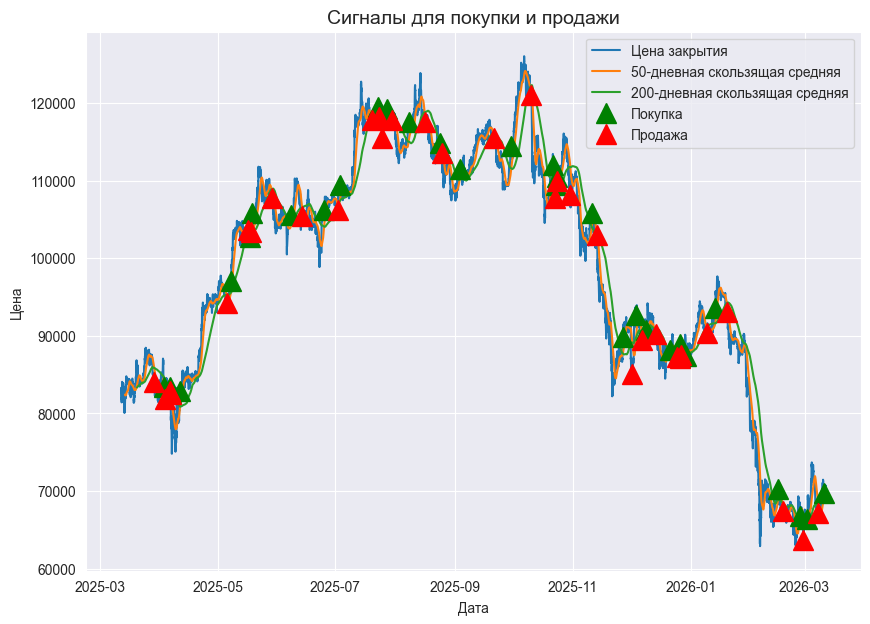

In [3]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы для покупки

data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

# Сигналы для продажи
data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

data['signal'] = data['buy'] + data['sell']

plot_data = data
plt.figure(figsize=(10, 7))
plt.title('Сигналы для покупки и продажи', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.plot(plot_data['close'], label='Цена закрытия')
plt.plot(plot_data['SMA50'], label='50-дневная скользящая средняя')
plt.plot(plot_data['SMA200'], label='200-дневная скользящая средняя')
plt.plot(plot_data[data['signal'] == 1]['close'],
'^', ms=15, label='Покупка', color='green')
plt.plot(plot_data[data['signal'] == -1]['close'],
'^', ms=15, label='Продажа', color='red')
plt.legend()
plt.show()

In [5]:
# Расчет дневной доходности
data['Returns'] = data['close'].resample('D').last().pct_change()
print(f"Средняя дневная доходность: {data['Returns'].mean()*100:.4f}%")
print(f"Волатильность: {data['Returns'].std()*100:.3f}%")

Средняя дневная доходность: -0.0170%
Волатильность: 2.311%


In [8]:
data['Returns'] = data['close'].pct_change()
# Моделирование результатов стратегии
data['Strategy_Returns'] = data['signal'].shift(1) * data['Returns']
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()
data['Cumulative_Market_Returns'] = (1 + data['Returns']).cumprod()

# Сравнение результатов
print(f"Общая доходность стратегии: {(data['Cumulative_Strategy_Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Общая доходность рынка: {(data['Cumulative_Market_Returns'].iloc[-1] - 1) * 100:.2f}%")

Общая доходность стратегии: -2.29%
Общая доходность рынка: -14.95%


In [61]:
# Бэктестинг
initial_capital = 10000
trade_fraction = 0.1


portfolio = data[['open', 'close', 'signal']]
portfolio['initial_capital'] = initial_capital
portfolio['trade_fraction'] = trade_fraction * portfolio['initial_capital']
portfolio['position_size'] = portfolio['trade_fraction'] / portfolio['open']


# portfolio['investments'] = portfolio['signal'] *
# portfolio['cash'] = portfolio['initial_capital'] - portfolio['signal'] *

commission = 0.000  # 0.0% комиссия
#trade_fraction = 0.1  # 10% от портфеля на одну сделку
#trade_amount = 100 # фикс сумма на сделку

# Изменение цены
data['returns'] = data['open'].pct_change()

data['strategy_returns'] = data['returns'] * data['signal'].shift(1)

In [62]:
portfolio

,open,signal,initial_capital,trade_fraction,position_size
timestamp,,,,,
2025-03-11 22:00:00,83110.71,0,10000,1000.0,0.012032
2025-03-11 23:00:00,83133.48,0,10000,1000.0,0.012029
2025-03-12 00:00:00,82932.99,0,10000,1000.0,0.012058
2025-03-12 01:00:00,82765.52,0,10000,1000.0,0.012082
2025-03-12 02:00:00,83313.60,0,10000,1000.0,0.012003
...,...,...,...,...,...
2026-03-11 17:00:00,70570.71,0,10000,1000.0,0.014170
2026-03-11 18:00:00,70785.99,0,10000,1000.0,0.014127
2026-03-11 19:00:00,70617.63,0,10000,1000.0,0.014161
